# Tarefa 2 — Otimizacao de hiperparametros do MNIST com Optuna

Aluno: Lucas Medeiros — Disciplina: Aprendizado Profundo — PPgTI/IMD/UFRN

Baseado no notebook do professor `mnist_keras.ipynb`. Busca de hiperparametros de uma MLP
com Optuna (20 trials), depois treino do modelo final com os melhores hiperparametros
encontrados e avaliacao completa no conjunto de teste.


In [6]:
pip install optuna tensorflow scikit-learn pandas

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 7.9/351.2 MB 40.5 MB/s eta 0:00:09
   - -------------------------------------- 16.8/351.2 MB 41.3 MB/s eta 0:00:09
   -- ------------------------------------- 25.4/351.2 MB 42.0 MB/s eta 0:00:08
   --- ------------------------------------ 34.3/351.2 MB 42.1 MB/s eta 0:00:08
   ---- ----------------------------------- 41.4/351.2 MB 40.5 MB/s eta 0:00:08
   ----- ---------------------------------- 50.1/351.2 MB 40.7 MB/s eta 0:00:08
   ------ --------------------------------- 57.7/351.2 MB 40.4 MB/s eta 0:00:08
   ------- -------------------------------- 66.1/351.2 MB 40.4 MB/s eta 0:00:08
   -------- ------------------------------- 75.2/351.2 MB 40.9 MB/s eta 0:00:07
   --------- ------------------------------ 84.4/351.2 MB 41.3 MB/s eta 0:00:07
   ---------- ----------------------------- 94.1/351.2 MB 41.9 MB/s eta 0:00:07
   ----------- --------------------------- 104.3/3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [7]:


import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(x_train.shape, x_test.shape)


c:\Users\lucas\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TF: 2.21.0
GPU: []
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (10000, 28, 28)


In [8]:
def build_model(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    units0 = trial.suggest_categorical("units", [32, 64, 128])
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    drop_rate = trial.suggest_float("drop_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    model = keras.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28)))
    for i in range(n_layers):
        model.add(layers.Dense(units0, activation=activation))
        if drop_rate > 0:
            model.add(layers.Dropout(drop_rate))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def objective(trial):
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    model = build_model(trial)
    history = model.fit(
        x_train, y_train,
        validation_split=0.1,
        epochs=8,
        batch_size=batch_size,
        verbose=0,
    )
    val_acc = history.history["val_accuracy"][-1]
    return val_acc


study = optuna.create_study(direction="maximize", study_name="mnist_mlp")
study.optimize(objective, n_trials=20)

print("Melhor acuracia de validacao:", study.best_value)
print("Melhores hiperparametros:", study.best_params)


[I 2026-09-03 21:12:40,778] A new study created in memory with name: mnist_mlp
c:\Users\lucas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2026-09-03 21:12:50,447] Trial 0 finished with value: 0.9691666960716248 and parameters: {'batch_size': 128, 'n_layers': 1, 'units': 64, 'activation': 'relu', 'drop_rate': 0.4987598897540318, 'learning_rate': 0.002060472371025463}. Best is trial 0 with value: 0.9691666960716248.
[I 2026-09-03 21:13:04,704] Trial 1 finished with value: 0.9649999737739563 and parameters: {'batch_size': 64, 'n_layers': 1, 'units': 32, 'activation': 'tanh', 'drop_rate': 0.029146261745204682, 'learning_rate': 0.004780870819637624}. Best is trial 0 with value: 0.9691666960716248.
[I 2026-09-03 21:13:15,669

Melhor acuracia de validacao: 0.9808333516120911
Melhores hiperparametros: {'batch_size': 128, 'n_layers': 2, 'units': 128, 'activation': 'relu', 'drop_rate': 0.11254174667932393, 'learning_rate': 0.00242859916890213}


Usando melhores hiperparametros: {'batch_size': 128, 'n_layers': 2, 'units': 128, 'activation': 'relu', 'drop_rate': 0.11254174667932393, 'learning_rate': 0.00242859916890213}


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_20 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9109 - loss: 0.2988 - val_accuracy: 0.9680 - val_loss: 0.1081
Epoch 2/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9586 - loss: 0.1347 - val_accuracy: 0.9748 - val_loss: 0.0878
Epoch 3/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9693 - loss: 0.0996 - val_accuracy: 0.9752 - val_loss: 0.0855
Epoch 4/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9744 - loss: 0.0806 - val_accuracy: 0.9800 - val_loss: 0.0704
Epoch 5/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.0714 - val_accuracy: 0.9782 - val_loss: 0.0825
Epoch 6/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9800 - loss: 0.0613 - val_accuracy: 0.9817 - val_loss: 0.0716
Epoch 7/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9823 - loss: 0.0556 - val_accuracy: 0.9823 - val_loss: 0.0667
Epoch 8/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9834 - loss: 0.0501 - val_accuracy: 0.

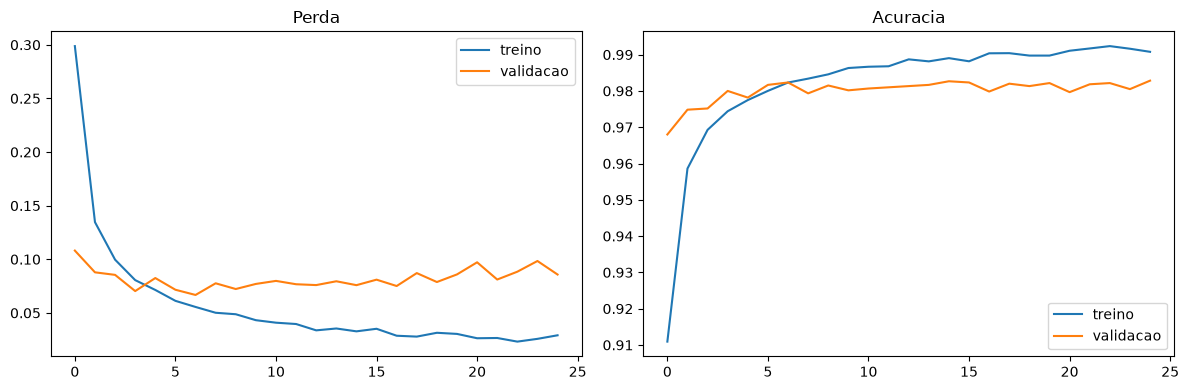

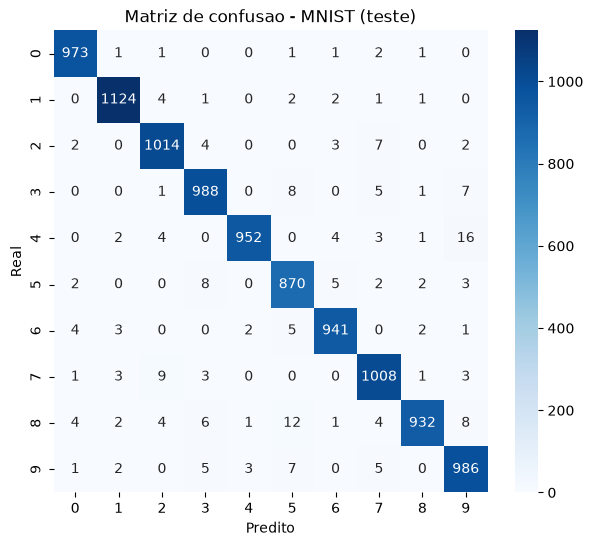

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.96      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



C:\Users\lucas\AppData\Local\Temp\ipykernel_10368\2222010363.py:58: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_optimization_history(study)


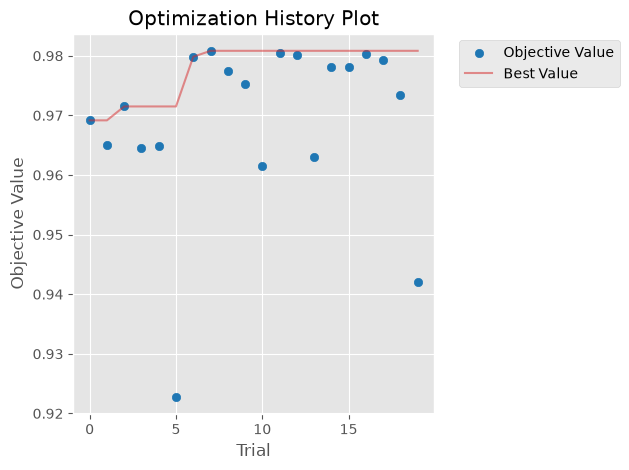

C:\Users\lucas\AppData\Local\Temp\ipykernel_10368\2222010363.py:61: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study)


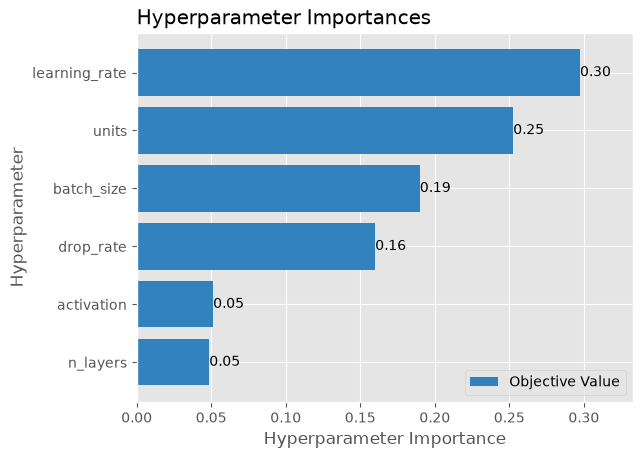

In [9]:
best = study.best_params
print("Usando melhores hiperparametros:", best)

final_model = keras.Sequential()
final_model.add(layers.Flatten(input_shape=(28, 28)))
for i in range(best["n_layers"]):
    final_model.add(layers.Dense(best["units"], activation=best["activation"]))
    if best["drop_rate"] > 0:
        final_model.add(layers.Dropout(best["drop_rate"]))
final_model.add(layers.Dense(10, activation="softmax"))

final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
final_model.summary()

history = final_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=25,
    batch_size=best["batch_size"],
    verbose=1,
)

test_loss, test_acc = final_model.evaluate(x_test, y_test, verbose=0)
print(f"\nAcuracia final no conjunto de TESTE: {test_acc:.4f}")
print(f"Perda final no conjunto de TESTE: {test_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="treino")
axes[0].plot(history.history["val_loss"], label="validacao")
axes[0].set_title("Perda")
axes[0].legend()
axes[1].plot(history.history["accuracy"], label="treino")
axes[1].plot(history.history["val_accuracy"], label="validacao")
axes[1].set_title("Acuracia")
axes[1].legend()
plt.tight_layout()
plt.savefig("curvas_treinamento.png", dpi=120)
plt.show()

y_pred = np.argmax(final_model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusao - MNIST (teste)")
plt.savefig("matriz_confusao.png", dpi=120)
plt.show()

print(classification_report(y_test, y_pred))

import optuna.visualization.matplotlib as ovm
try:
    ovm.plot_optimization_history(study)
    plt.savefig("optuna_history.png", dpi=120)
    plt.show()
    ovm.plot_param_importances(study)
    plt.savefig("optuna_importances.png", dpi=120)
    plt.show()
except Exception as e:
    print("Aviso ao plotar historico do optuna:", e)
